# Iris Flower Classification — Model Evaluation

## Objective

The objective of this stage is to evaluate the performance of the trained Iris flower classification model using standard classification metrics.

The evaluation focuses on:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix

The model is evaluated using the unseen test dataset so that its performance reflects how well it generalizes to new data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from src.model import run_classification

In [2]:
# Define the project root and dataset path
project_root = Path(r"C:\iris-flower-classification")
data_path = project_root / "data" / "iris_cleaned.csv"

# Run the classification workflow
model, X_test, y_test, y_pred = None, None, None, None

(
    model,
    X_test,
    y_test,
    y_pred,
    results
) = __import__("src.evaluation", fromlist=["run_evaluation"]).run_evaluation(data_path)

print("Evaluation data loaded successfully.")
print("Test samples:", len(y_test))
print("Predictions:", len(y_pred))

Evaluation data loaded successfully.
Test samples: 30
Predictions: 30


In [3]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")
print(f"F1-score : {f1:.2%}")

Accuracy : 93.33%
Precision: 93.33%
Recall   : 93.33%
F1-score : 93.33%


In [4]:
# Generate the detailed classification report

report = classification_report(
    y_test,
    y_pred,
    zero_division=0
)

print(report)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [5]:
# Calculate the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


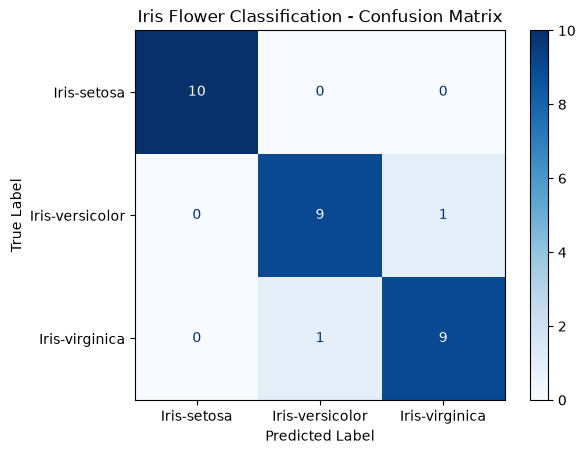

In [6]:
# Visualize the confusion matrix

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Iris-setosa", "Iris-versicolor", "Iris-virginica"]
).plot(cmap="Blues")

plt.title("Iris Flower Classification - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Evaluation Interpretation

The Logistic Regression model achieved an overall test accuracy of **93.33%**, correctly classifying 28 out of 30 unseen test samples.

The confusion matrix shows that:

- **Iris-setosa** was classified perfectly, with all 10 test samples correctly predicted.
- **Iris-versicolor** had 9 correct predictions, with 1 sample classified as Iris-virginica.
- **Iris-virginica** had 9 correct predictions, with 1 sample classified as Iris-versicolor.

The model achieved **93.33% weighted precision, recall, and F1-score**, indicating good and balanced classification performance on the test dataset.

The two classification errors occurred between Iris-versicolor and Iris-virginica, which are more similar in their flower measurements than Iris-setosa.

## Conclusion

The evaluation demonstrates that the Logistic Regression model performs well on the Iris dataset. It achieved **93.33% accuracy** on unseen test data and classified Iris-setosa without any errors.

Although there were two misclassifications between Iris-versicolor and Iris-virginica, the overall performance was strong. The results show that the selected features and classification approach are effective for predicting Iris flower species.